In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 69.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 108.8 MB/s eta 0:00:0000:0100:01


In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Setup GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# CIFAR-10 class names
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

#  Enhanced Data Loading with Subsetting
def load_data(classes=[0,1], max_samples_per_class=200, test_samples_per_class=50):
    """Load subset of CIFAR10 with specified classes and sample sizes"""
    transform = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((8, 8)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # Load full datasets
    trainset = CIFAR10('./data', train=True, download=True, transform=transform)
    testset = CIFAR10('./data', train=False, transform=transform)

    def filter_dataset(dataset, max_samples=None):
        x, y = [], []
        counts = {c:0 for c in classes}
        for img, label in dataset:
            if label in classes and counts[label] < (max_samples or float('inf')):
                x.append(img.view(-1))
                y.append(classes.index(label))  # Remap to 0,1,2...
                counts[label] += 1
                if all(c >= (max_samples or float('inf')) for c in counts.values()):
                    break
        return torch.stack(x), torch.tensor(y)

    x_train, y_train = filter_dataset(trainset, max_samples_per_class)
    x_test, y_test = filter_dataset(testset, test_samples_per_class)

    print(f"Loaded {len(x_train)} training samples and {len(x_test)} test samples")
    print(f"Class distribution - Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")

    return x_train, y_train, x_test, y_test, [cifar10_classes[c] for c in classes]

def pool_to_qubits(image, n_qubits):
    """Convert 8x8 image to n_qubits features using adaptive pooling"""
    # Reshape from 64 to 8x8
    img_2d = image.view(-1, 8, 8)

    # Calculate optimal pool size
    pool_size = 8 // int(np.ceil(np.sqrt(n_qubits)))
    pooled = F.avg_pool2d(img_2d, kernel_size=pool_size)
    flattened = pooled.flatten()

    # Pad or truncate
    if len(flattened) < n_qubits:
        padding = torch.zeros(n_qubits - len(flattened))
        return torch.cat([flattened, padding])
    return flattened[:n_qubits]


Using device: cuda


In [ ]:

n_qubits = 6
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(image, weights):

    inputs=pool_to_qubits(image,n_qubits)

    # Enhanced feature embedding
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RX(inputs[i], wires=i)
        qml.RZ(inputs[(i+1)%n_qubits], wires=i)

    # Two strong variational layers
    for layer in range(2):
        # Single-qubit rotations
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)

        # All-to-all entanglement
        for i in range(n_qubits):
            for j in range(i+1, min(i+3, n_qubits)):  # Limited connectivity
                qml.CRZ(weights[layer, i, j], wires=[i,j])

    # Final rotations
    for i in range(n_qubits):
        qml.RY(weights[-1, i, 0], wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

#  Enhanced Quantum Layer with GPU support
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.n_qubits = n_qubits
        self.weights = nn.Parameter(torch.rand(4, n_qubits, n_qubits, dtype=torch.float32))

    def forward(self, x):
        x = x.float().to(device)
        if len(x.shape) == 1:
            x = x.unsqueeze(0)

        batch_outputs = []
        for i in range(x.shape[0]):
            out = quantum_circuit(x[i].cpu(), self.weights.cpu())
            batch_outputs.append(torch.stack(out).float().to(device))

        return torch.stack(batch_outputs)

# Complete Hybrid Model
class QuantumClassifier(nn.Module):
    def __init__(self, n_qubits, n_classes):
        super().__init__()
        self.quantum = QuantumLayer(n_qubits)
        self.classical = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        ).to(device)

    def forward(self, x):
        x = x.float().to(device)
        x = self.quantum(x)
        return self.classical(x)


In [ ]:
#  Visualization and Evaluation Functions
def plot_confusion_matrix(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

def draw_quantum_circuit(model):
    print("\nQuantum Circuit Visualization:")
    try:
        # Get sample input and weights
        sample_input = torch.randn(n_qubits).cpu().numpy()
        weights = model.quantum.weights.detach().cpu().numpy()

        # Create a dummy circuit for visualization
        @qml.qnode(dev, interface="numpy")
        def circuit_to_draw(inputs, weights):
            # Simplified version for visualization
            for i in range(n_qubits):
                qml.RY(inputs[i], wires=i)
                qml.RZ(weights[0, i, 0], wires=i)
            for i in range(n_qubits-1):
                qml.CNOT(wires=[i, i+1])
            return qml.expval(qml.PauliZ(0))

        fig, ax = qml.draw_mpl(circuit_to_draw)(sample_input, weights)
        plt.title("Quantum Circuit Structure")
        plt.show()
    except Exception as e:
        print(f"Could not draw circuit: {e}")

def class_wise_accuracy(model, test_loader, class_names):
    model.eval()
    class_correct = [0] * len(class_names)
    class_total = [0] * len(class_names)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            c = (preds == labels)

            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    # Plot class-wise accuracy
    plt.figure(figsize=(10,5))
    plt.bar(class_names, [class_correct[i]/class_total[i] for i in range(len(class_names))])
    plt.title('Class-wise Accuracy')
    plt.xlabel('Class')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.show()


In [ ]:
def train_and_evaluate(classes=[0,1], train_samples=200, test_samples=50, epochs=15):
    # Load subsetted data
    x_train, y_train, x_test, y_test, class_names = load_data(
        classes=classes,
        max_samples_per_class=train_samples,
        test_samples_per_class=test_samples
    )

    # Data loaders
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=len(x_test))

    # Initialize model
    model = QuantumClassifier(n_qubits, len(classes)).to(device)
    opt = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()

            total_loss += loss.item()
            _, preds = torch.max(out, 1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        # Print training progress
        train_acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Train Acc: {train_acc*100:.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        xb, yb = next(iter(test_loader))
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        preds = out.argmax(dim=1)
        test_acc = accuracy_score(yb.cpu(), preds.cpu())
        print(f"\nTest Accuracy: {test_acc*100:.4f}")

    # Visualizations
    plot_confusion_matrix(model, test_loader, class_names)
    draw_quantum_circuit(model)
    class_wise_accuracy(model, test_loader, class_names)

    return test_acc


Training on classes: ['bird', 'ship']
Files already downloaded and verified
Loaded 4000 training samples and 800 test samples
Class distribution - Train: [2000 2000], Test: [400 400]
Epoch 1/15 | Loss: 76.6555 | Train Acc: 67.3750
Epoch 2/15 | Loss: 74.7075 | Train Acc: 69.0750
Epoch 3/15 | Loss: 73.0962 | Train Acc: 69.2250
Epoch 4/15 | Loss: 72.9167 | Train Acc: 70.0750
Epoch 5/15 | Loss: 73.0731 | Train Acc: 69.6000
Epoch 6/15 | Loss: 72.1486 | Train Acc: 70.4750
Epoch 7/15 | Loss: 73.0643 | Train Acc: 70.1750
Epoch 8/15 | Loss: 72.5623 | Train Acc: 70.1000
Epoch 9/15 | Loss: 71.4341 | Train Acc: 70.9000
Epoch 10/15 | Loss: 71.9844 | Train Acc: 70.5750
Epoch 11/15 | Loss: 72.2711 | Train Acc: 70.5250
Epoch 12/15 | Loss: 71.5618 | Train Acc: 71.0750
Epoch 13/15 | Loss: 71.7083 | Train Acc: 70.8000
Epoch 14/15 | Loss: 72.0053 | Train Acc: 70.7000
Epoch 15/15 | Loss: 71.2896 | Train Acc: 70.9500

Test Accuracy: 73.0000


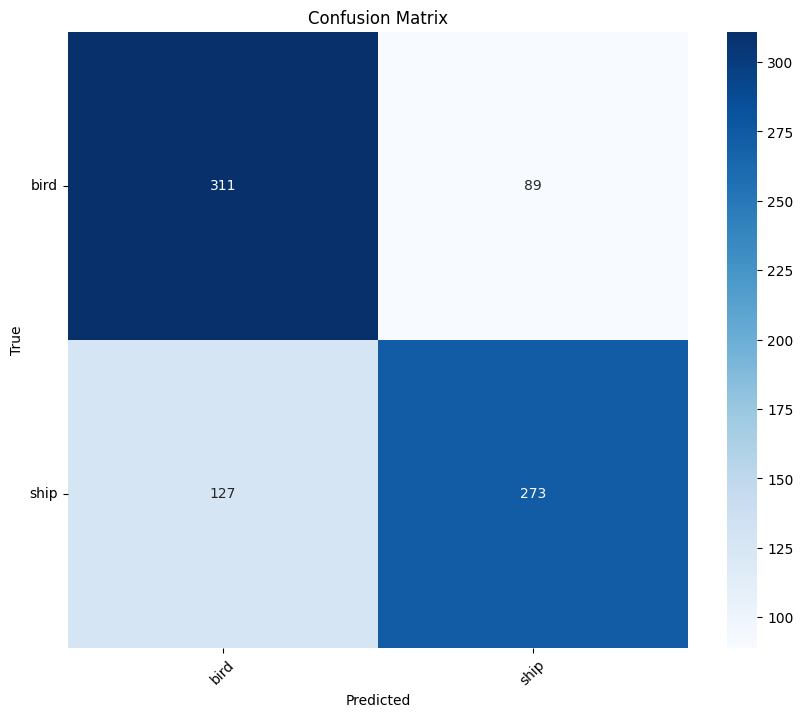


Classification Report:
              precision    recall  f1-score   support

        bird       0.71      0.78      0.74       400
        ship       0.75      0.68      0.72       400

    accuracy                           0.73       800
   macro avg       0.73      0.73      0.73       800
weighted avg       0.73      0.73      0.73       800


Quantum Circuit Visualization:


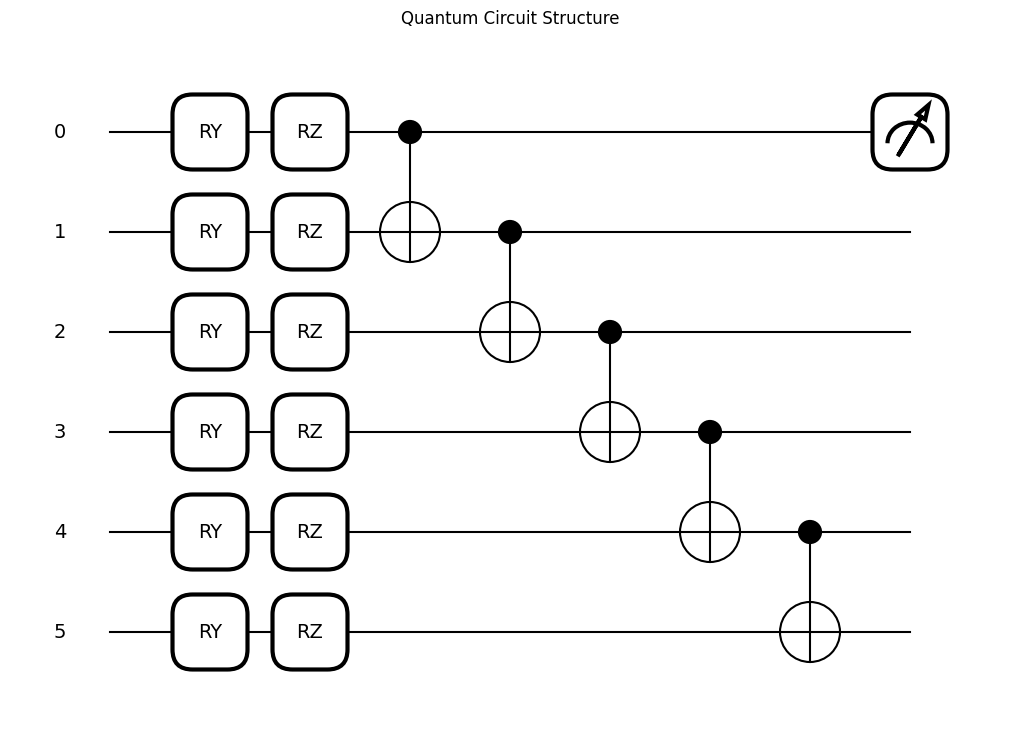

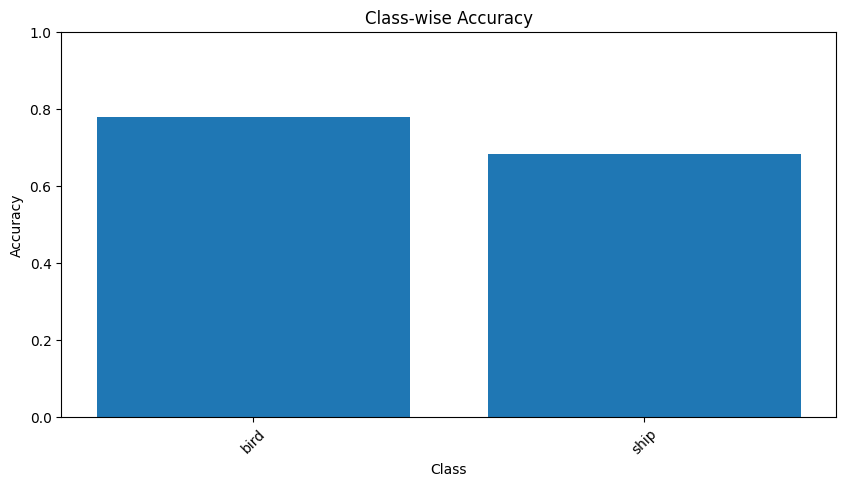


Training on classes: ['airplane', 'cat', 'dog']
Files already downloaded and verified
Loaded 6000 training samples and 1200 test samples
Class distribution - Train: [2000 2000 2000], Test: [400 400 400]
Epoch 1/15 | Loss: 188.5366 | Train Acc: 49.0667
Epoch 2/15 | Loss: 182.1324 | Train Acc: 51.6000
Epoch 3/15 | Loss: 180.1425 | Train Acc: 52.7333
Epoch 4/15 | Loss: 178.4065 | Train Acc: 52.8167
Epoch 5/15 | Loss: 179.4207 | Train Acc: 52.0167
Epoch 6/15 | Loss: 185.2237 | Train Acc: 50.0833
Epoch 7/15 | Loss: 178.0226 | Train Acc: 52.9000
Epoch 8/15 | Loss: 177.1275 | Train Acc: 52.9833
Epoch 9/15 | Loss: 177.9037 | Train Acc: 52.6167
Epoch 10/15 | Loss: 176.3348 | Train Acc: 53.9333
Epoch 11/15 | Loss: 177.4028 | Train Acc: 53.1333
Epoch 12/15 | Loss: 176.1715 | Train Acc: 52.9000
Epoch 13/15 | Loss: 176.6520 | Train Acc: 53.2833
Epoch 14/15 | Loss: 176.1477 | Train Acc: 53.8000
Epoch 15/15 | Loss: 176.2963 | Train Acc: 53.5667

Test Accuracy: 54.0000


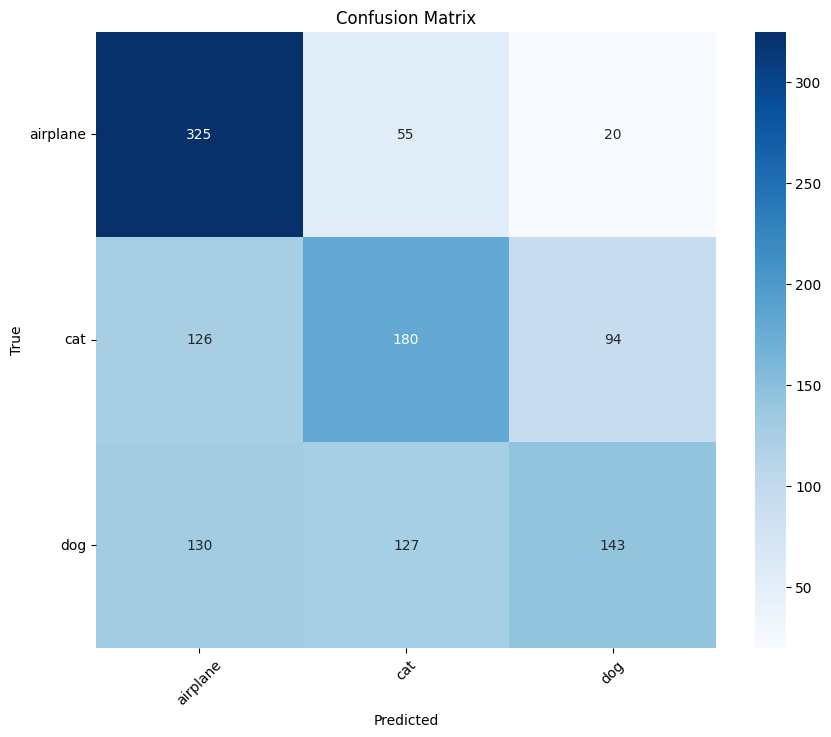


Classification Report:
              precision    recall  f1-score   support

    airplane       0.56      0.81      0.66       400
         cat       0.50      0.45      0.47       400
         dog       0.56      0.36      0.44       400

    accuracy                           0.54      1200
   macro avg       0.54      0.54      0.52      1200
weighted avg       0.54      0.54      0.52      1200


Quantum Circuit Visualization:


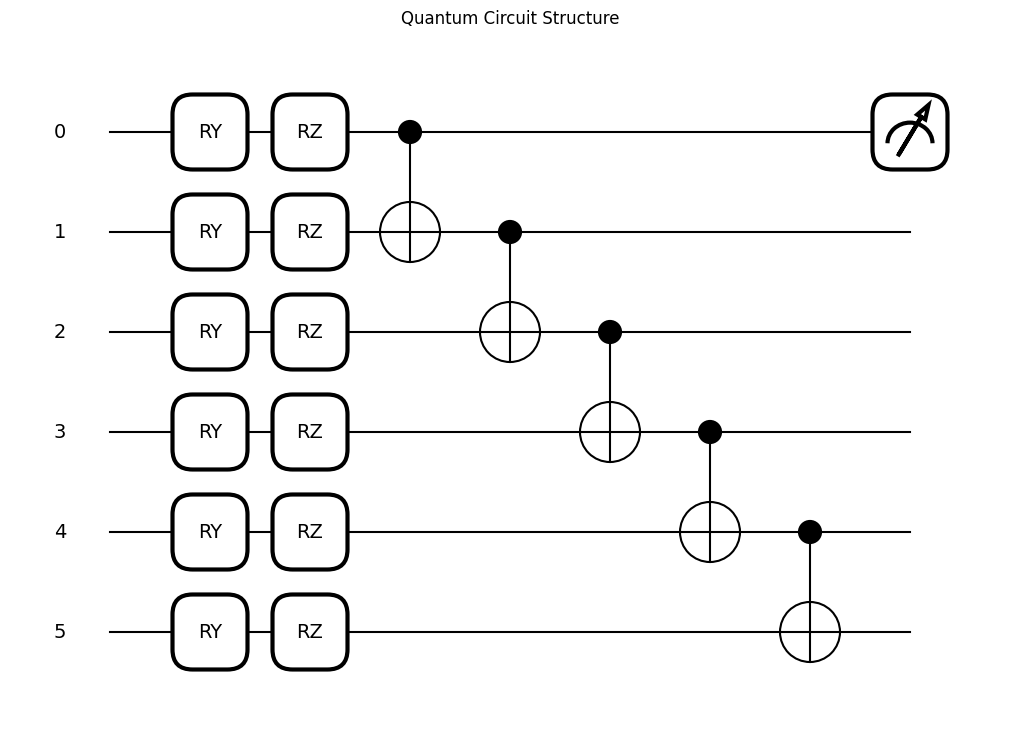

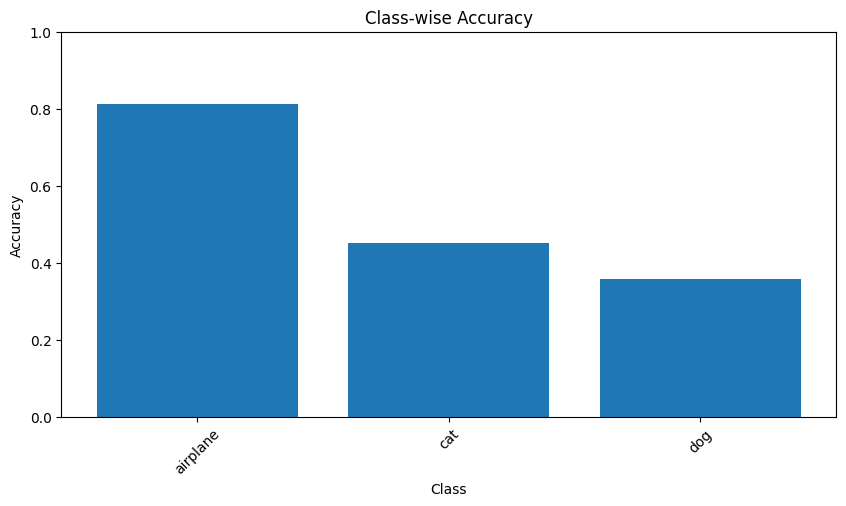


Training on classes: ['airplane', 'automobile', 'bird', 'cat', 'deer']
Files already downloaded and verified
Loaded 10000 training samples and 2000 test samples
Class distribution - Train: [2000 2000 2000 2000 2000], Test: [400 400 400 400 400]
Epoch 1/15 | Loss: 486.7988 | Train Acc: 29.7200
Epoch 2/15 | Loss: 478.8802 | Train Acc: 31.5100
Epoch 3/15 | Loss: 474.6613 | Train Acc: 32.5900
Epoch 4/15 | Loss: 471.5366 | Train Acc: 33.6000
Epoch 5/15 | Loss: 469.2498 | Train Acc: 34.2400
Epoch 6/15 | Loss: 467.4662 | Train Acc: 34.5600
Epoch 7/15 | Loss: 465.5583 | Train Acc: 34.9700
Epoch 8/15 | Loss: 465.2894 | Train Acc: 34.7400
Epoch 9/15 | Loss: 466.2253 | Train Acc: 34.7400
Epoch 10/15 | Loss: 465.5989 | Train Acc: 35.1600
Epoch 11/15 | Loss: 464.3339 | Train Acc: 35.6200
Epoch 12/15 | Loss: 465.4741 | Train Acc: 34.4600
Epoch 13/15 | Loss: 463.8210 | Train Acc: 36.0200
Epoch 14/15 | Loss: 466.5305 | Train Acc: 35.0900
Epoch 15/15 | Loss: 466.5070 | Train Acc: 35.1600

Test Accurac

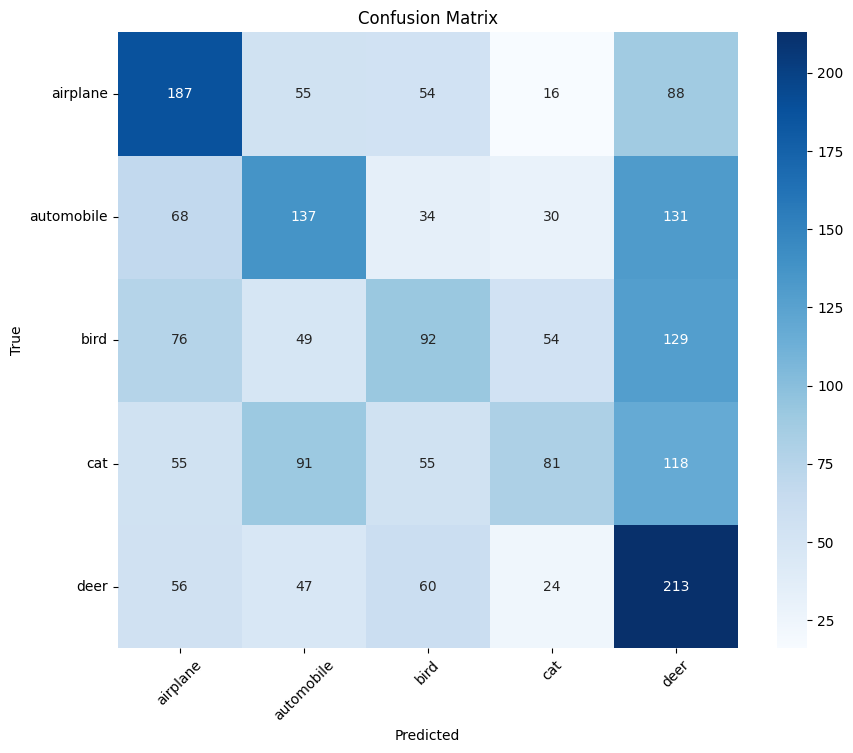


Classification Report:
              precision    recall  f1-score   support

    airplane       0.42      0.47      0.44       400
  automobile       0.36      0.34      0.35       400
        bird       0.31      0.23      0.26       400
         cat       0.40      0.20      0.27       400
        deer       0.31      0.53      0.39       400

    accuracy                           0.36      2000
   macro avg       0.36      0.36      0.34      2000
weighted avg       0.36      0.35      0.34      2000


Quantum Circuit Visualization:


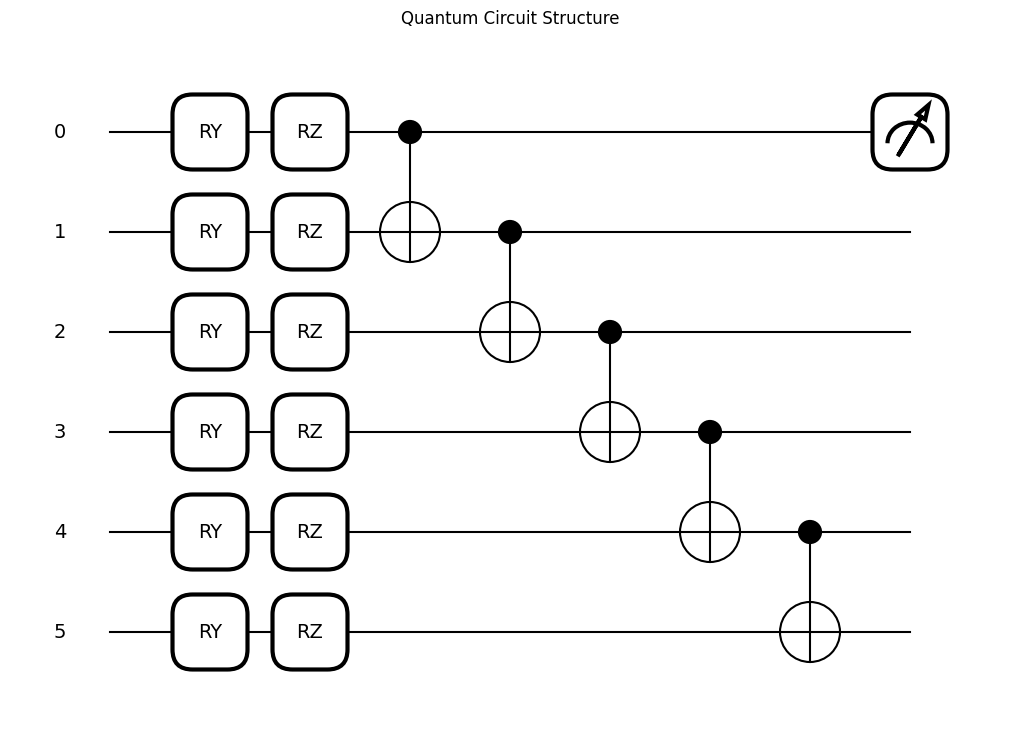

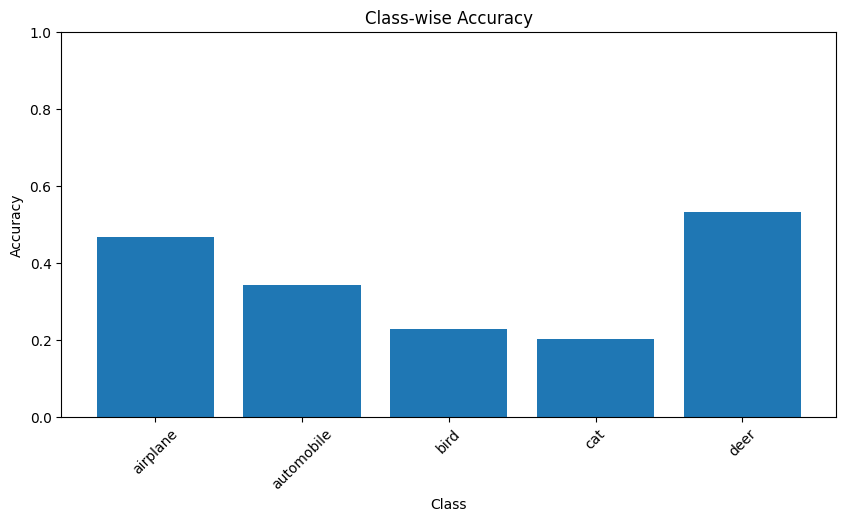


Final Results:
Classes ['bird', 'ship']: Accuracy = 73.0000
Classes ['airplane', 'cat', 'dog']: Accuracy = 54.0000
Classes ['airplane', 'automobile', 'bird', 'cat', 'deer']: Accuracy = 35.5000


In [ ]:
if __name__ == "__main__":
    # Try different class combinations
    class_combinations = [
        [2, 8],           # Binary
        [0, 3, 5],        # 3-class
        [0, 1, 2, 3, 4],  # 5-class
    ]

    results = {}
    for classes in class_combinations:
        print(f"\nTraining on classes: {[cifar10_classes[c] for c in classes]}")
        acc = train_and_evaluate(
            classes=classes,
            train_samples=2000,
            test_samples=400,
            epochs=15
        )
        results[tuple(classes)] = acc

    print("\nFinal Results:")
    for classes, acc in results.items():
        print(f"Classes {[cifar10_classes[c] for c in classes]}: Accuracy = {acc*100:.4f}")